## Exploratory data analysis on MISO load data.
Goal: Understand daily/weekly patterns and identify signals for forecasting model.

In [1]:
# Adjust path so the notebook can be run natively in VSCode
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from app.database import engine
import datetime

# Set plotting defaults
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# Load region-level rows, then derive the system-wide total per timestamp
# load_actuals stores one row per (timestamp, region), summing across regions
region_df = pd.read_sql("SELECT * FROM load_actuals;", con=engine)
region_df["timestamp"] = pd.to_datetime(region_df["timestamp"])

df = (
    region_df.groupby("timestamp", as_index=False)["load_mw"].sum()
    .sort_values("timestamp")
    .reset_index(drop=True)
)
df.head()

,timestamp,load_mw
0,2026-06-01 00:00:00,68955
1,2026-06-01 01:00:00,66678
2,2026-06-01 02:00:00,65332
3,2026-06-01 03:00:00,65117
4,2026-06-01 04:00:00,66408


In [3]:
# Data Quality
# Check for duplicate timestamps
duplicates = df[df.duplicated(subset="timestamp", keep=False)]

print(f"Found {len(duplicates)} duplicate timestamp rows.")
if len(duplicates) > 0:
    print(duplicates)
print("\n")

# Check for gaps in time coverage
full_range = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing = full_range.difference(df["timestamp"])

print(f"Expected {len(full_range)} hourly timestamps, found {df["timestamp"].nunique()} unique. Missing: {len(missing)} hours.")
if len(missing) > 0:
    print(missing)
print("\n")

# Check for implausible values, like 0's, negatives, or unexpectedly large values
zeros = df[df["load_mw"] == 0]
negatives = df[df["load_mw"] < 0]
large = df[df["load_mw"] > 150000] # implement statistical bounds?
implausible_values = pd.concat([zeros, negatives, large], ignore_index=True)

print(f"Found {len(zeros)} zeros. Found {len(negatives)} negative values. Found {len(large)} large values.")
if len(implausible_values) > 0:
    print(implausible_values)

Found 0 duplicate timestamp rows.


Expected 720 hourly timestamps, found 720 unique. Missing: 0 hours.


Found 0 zeros. Found 0 negative values. Found 0 large values.


In [4]:
# Break timestamp into hour, day of the week, and date
df = df.set_index("timestamp")
df["hour"] = df.index.hour
df["day_of_week"] = df.index.day_name()
df["date"] = df.index.date

# Create load lag columns, reflecting the load 1/24/168 hours before the current timestamp
df["load_mw_lag_1h"] = df["load_mw"].shift(1)
df["load_mw_lag_24h"] = df["load_mw"].shift(24)
df["load_mw_lag_168h"] = df["load_mw"].shift(168)

# Function to fetch data for a specified window of time
def filter_by_date(df: pd.DataFrame, start: datetime, end: datetime) -> pd.DataFrame:
    mask = (df.index >= start) & (df.index <= end)
    return df[mask]

# Full Load Profile
Plotting the shape of all total load data to understand recurring trends.

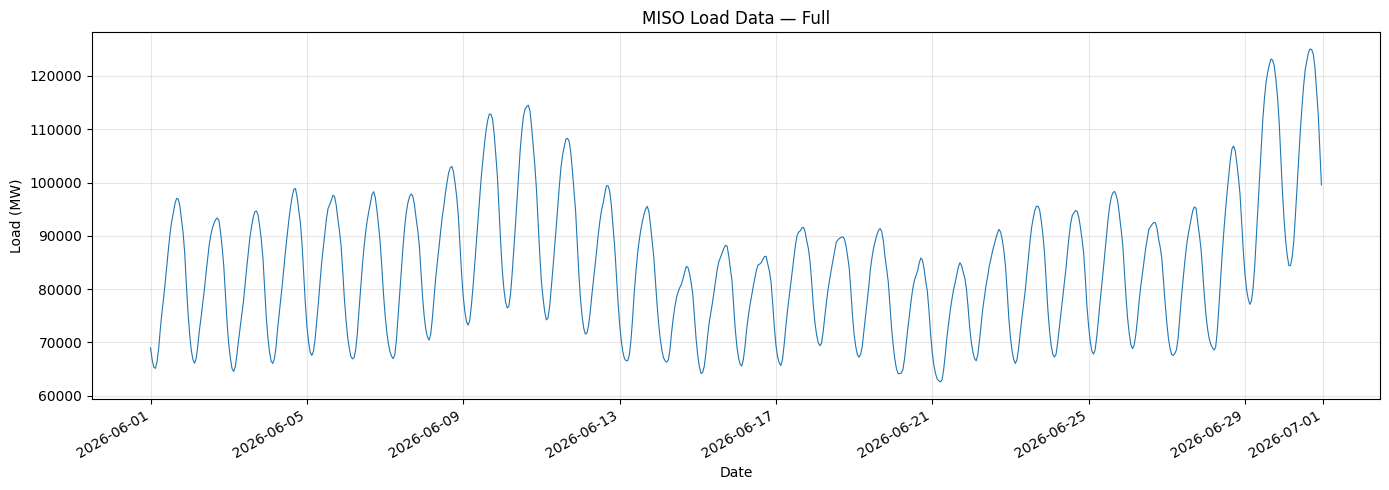

In [5]:
# Plot the full load history
fig, ax = plt.subplots()
ax.plot(df.index, df["load_mw"], linewidth=0.8)
ax.set_title("MISO Load Data — Full")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()  # rotate date labels so they don't overlap
plt.tight_layout()
plt.show()

The shape of the full load data is cyclical, which is expected.

In [12]:
# # Plot a single week's history (first 168 hours of load data)
# filtered_df = filter_by_date(df, datetime.datetime(2026, 6, 1, 0), datetime.datetime(2026, 6, 7, 23))

# fig, ax = plt.subplots()
# ax.plot(filtered_df.index, filtered_df["load_mw"], linewidth=0.8)
# ax.set_title("MISO Load Data — One Week")
# ax.set_xlabel("Date")
# ax.set_ylabel("Load (MW)")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

In [13]:
# # Plot a single day's history (first 24 hours of load data)
# filtered_df = filter_by_date(df, datetime.datetime(2026, 6, 1, 0), datetime.datetime(2026, 6, 1, 23))

# fig, ax = plt.subplots()
# ax.plot(filtered_df.index, filtered_df["load_mw"], linewidth=0.8)
# ax.set_title("MISO Load Data — One Day")
# ax.set_xlabel("Time")
# ax.set_ylabel("Load (MW)")
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

# Average Daily Profiles
Plotting the average daily profile, as well as +1 and -1 standard deviation, to closer analyze trends within a single day.
Plotting the average daily profile by the day of the week to compare profiles throughout the week.

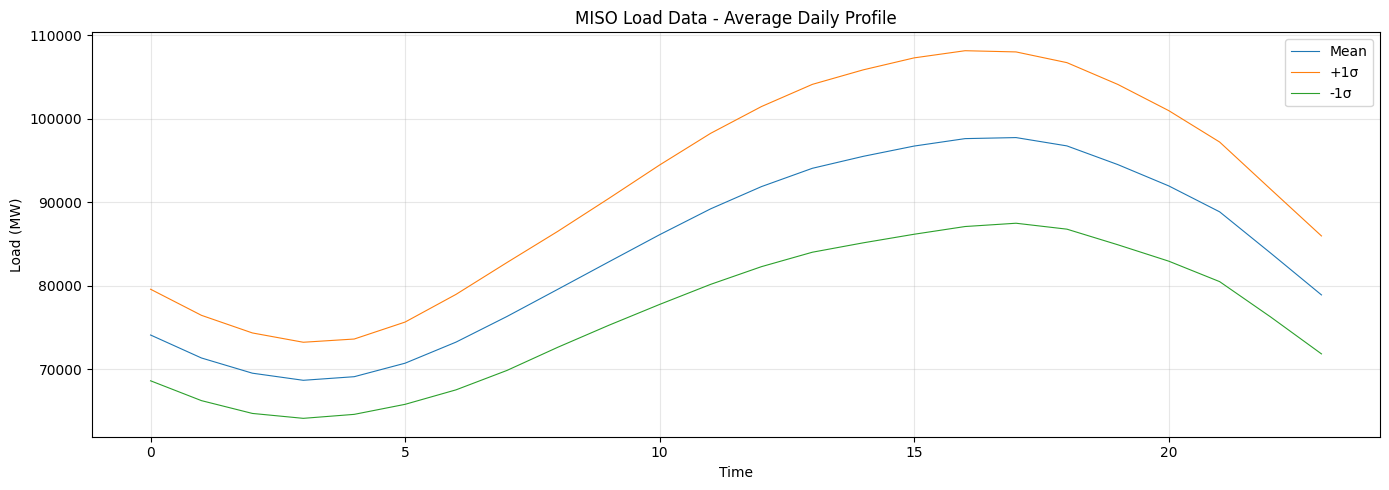

In [8]:
# Average daily profile
# Group by hour and plot mean & standard deviation to analyze the average day
hourly_stats = df.groupby("hour")["load_mw"].agg(["mean", "std"])

fig, ax = plt.subplots()
ax.plot(hourly_stats.index, hourly_stats["mean"], linewidth=0.8, label="Mean")
ax.plot(hourly_stats.index, hourly_stats["mean"] + hourly_stats["std"], linewidth=0.8, label="+1σ")
ax.plot(hourly_stats.index, hourly_stats["mean"] - hourly_stats["std"], linewidth=0.8, label="-1σ")
ax.set_title("MISO Load Data - Average Daily Profile")
ax.set_xlabel("Time")
ax.set_ylabel("Load (MW)")
plt.tight_layout()
plt.legend()
plt.show()

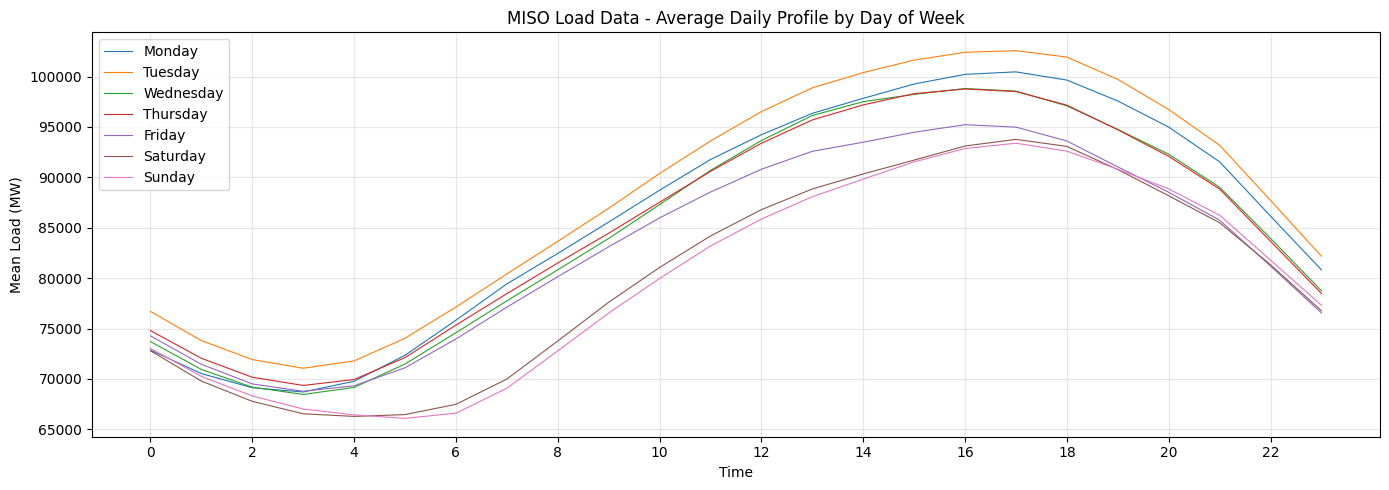

In [ ]:
# Average daily profile by day of week
# Group by day of week and hour, plot mean analyze the average day by day of the week
day_of_week_stats = df.groupby(["day_of_week", "hour"])["load_mw"].mean().unstack("day_of_week")
day_of_week_stats = day_of_week_stats[["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]]

fig, ax = plt.subplots()

for day in day_of_week_stats.columns:
    ax.plot(day_of_week_stats.index, day_of_week_stats[day], linewidth=0.8, label=day)

ax.set_title("MISO Load Data - Average Daily Profile by Day of Week")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Load (MW)")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.legend()
plt.show()

Above is the average daily profile for each day of the week. It's clear that weekdays see a higher average load at all hours of the day than weekends, making weekday/weekend differentiation potentially impactful for forecasting. Notably, Tuesday sees the highest average load, and drops throughout the week.

# Autocorrelation
Plotting autocorrelation graphs with statsmodels library to analyze how meaningful previous load values (at t-1h to t-180h) are to predicting a future load value.

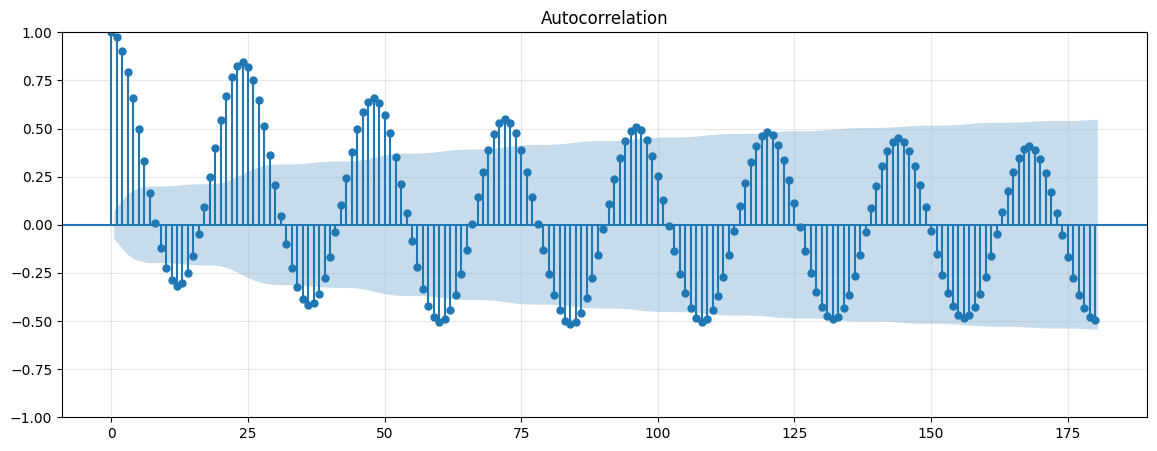

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Lag autocorrelation
# Determines signal for load values at t-1 hours to t-180 hours
# ACF
plot_acf(df["load_mw"], lags=180)
plt.show()

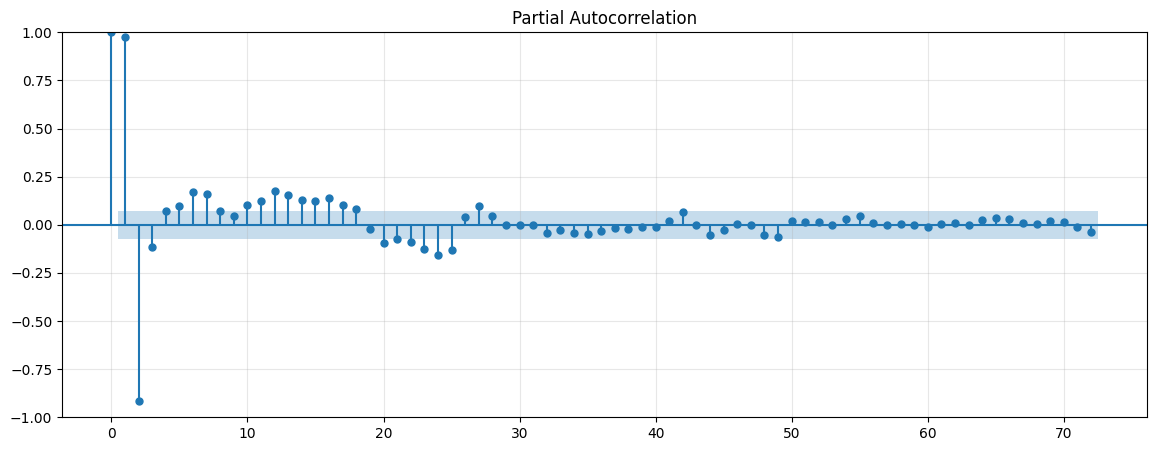

In [11]:
# PACF
plot_pacf(df["load_mw"], lags=72, method="ywm")
plt.show()

The PACF chart shows which lags are valuable to predicting a future load value. The score is significant for lags t-1h and t-2h, making them potentially strong signals for the forecasting model. The t-24h lag may also be significant.